# 8. Use text mining techniques to analyse a collection of news articles. Identify the most frequent terms and perform topic modelling using Latent Dirichlet Allocation (LDA) to find hidden topics within the articles.

use `Latent Dirichlet Allocation (LDA)`

Most Frequent Words:
            term  count
0          bank      1
1  breakthrough      1
2    celebrated      1
3       central      1
4  championship      1


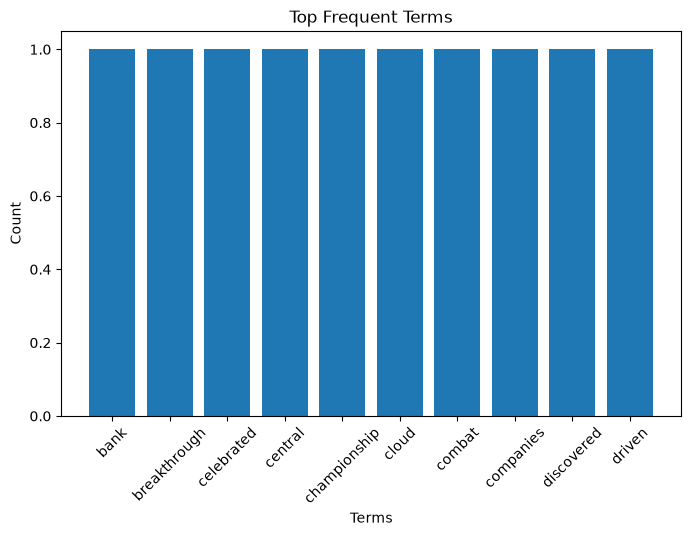


Topics Found by LDA:

Topic 0: ['inflation', 'rates', 'raised', 'central', 'bank']
Topic 1: ['cloud', 'driven', 'tech', 'strong', 'earnings']


In [1]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd


articles = [
    "The central bank raised interest rates to combat inflation.",
    "A wildfire spread across the region forcing thousands to evacuate.",
    "The football team won the championship and fans celebrated.",
    "Tech companies reported strong earnings driven by cloud services.",
    "Researchers discovered a breakthrough in renewable energy storage."
]


vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(articles)
terms = vectorizer.get_feature_names_out()


freq = X.toarray().sum(axis=0) # pyright: ignore[reportAttributeAccessIssue]
freq_df = pd.DataFrame({"term": terms, "count": freq}).sort_values(
    by="count", ascending=False
)

print("Most Frequent Words:\n", freq_df.head())


top_n = 10
top_terms = freq_df.head(top_n)

plt.figure(figsize=(8, 5))
plt.bar(top_terms['term'], top_terms['count'])
plt.title("Top Frequent Terms")
plt.xlabel("Terms")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)


print("\nTopics Found by LDA:\n")

for idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-5:][::-1]
    print(f"Topic {idx}: {[terms[i] for i in top_indices]}")